# **Detecção de forma OpenCV**

Como faço para calcular o centro de um contorno usando python+opencv?

Passos:

1. Conversão em escala de cinza.

2. Desfoque para reduzir o ruído de alta frequência para tornar nosso processo de detecção de contorno mais preciso.

3. Binarização da imagem. Normalmente, a detecção e o limiar de borda são usados para esse processo. Neste post, vamos aplicar o limiar.





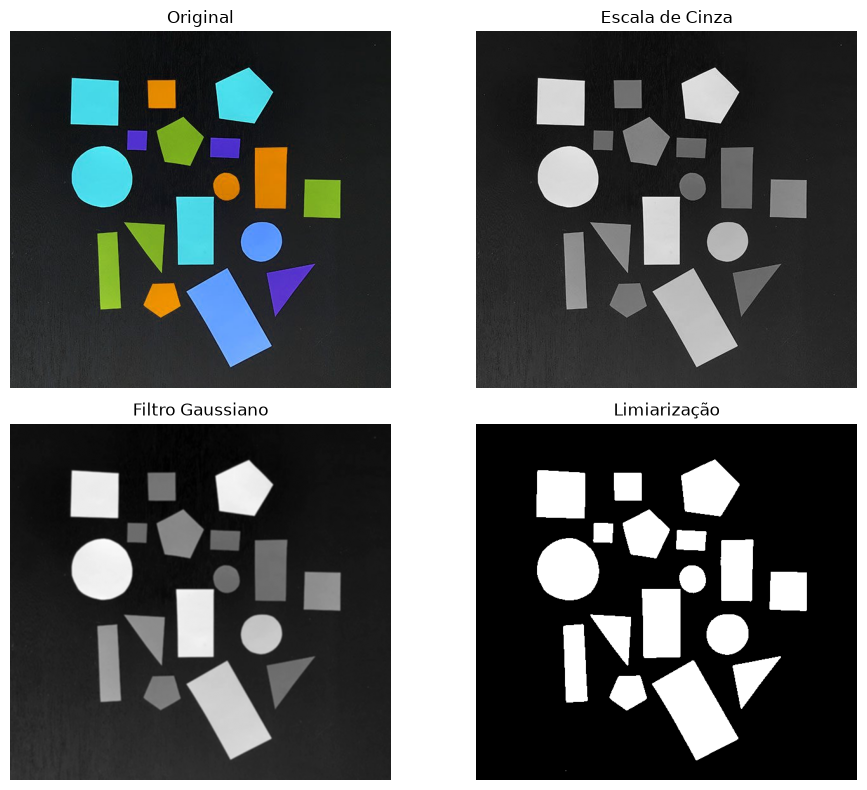

In [29]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("image/shapes_and_colors.jpg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gaussian = cv2.GaussianBlur(gray, (5,5),0)

ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax0, ax1, ax2, ax3 = axes.ravel()

ax0.imshow(image)
ax0.set_title("Original")
ax0.axis("off")

ax1.imshow(gray, cmap = 'gray')
ax1.set_title("Escala de Cinza")
ax1.axis("off")

ax2.imshow(gaussian, cmap = 'gray')
ax2.set_title("Filtro Gaussiano")
ax2.axis("off")

ax3.imshow(threshold, cmap = 'gray')
ax3.set_title("Limiarização")
ax3.axis("off")
plt.tight_layout()

O próximo passo é encontrar a localização dessas regiões brancas usando a detecção de contorno

(np.float64(-0.5), np.float64(599.5), np.float64(560.5), np.float64(-0.5))

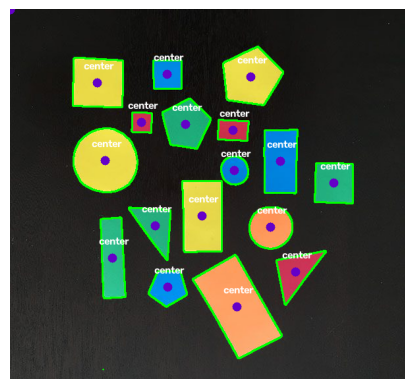

In [30]:
contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for c in contornos:
    # compute the center of the contour
    M = cv2.moments(c)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
        
    else:
        # Se m00 for zero, define uma coordenada padrão (ou ignora o contorno)
        cX, cY = 0, 0

    #draw the contour and center of the shape on the image
    cv2.drawContours(image, [c], -1, (0,255, 0), 2)
    cv2.circle(image, (cX,cY), 7, (200, 0, 100), -1)
    cv2.putText(image, "center", (cX -20, cY -20),cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)


    # show the image
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2.imwrite("output/centro.png", rgb)
plt.imshow(rgb)

plt.axis('off')


### **Detecção de formas** 

In [37]:
class ShapeDetector:
    def __init__(self):
        pass

    def detect(self, c):
        shape = "unidentified"
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.04 *peri, True)

        if len(approx) == 3:
            shape = "triangle"

        elif len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)
            ar = w/float(h)

            shape = "square" if ar>=0.95 and ar<= 1.05 else "rectangle"

        elif len(approx) == 5:
            shape = "pentagon"

        else:
            shape = "circle"

        return shape



(np.float64(-0.5), np.float64(599.5), np.float64(560.5), np.float64(-0.5))

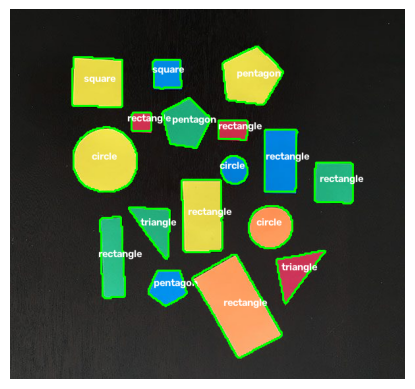

In [38]:
image = cv2.imread("image/shapes_and_colors.jpg")

scale = 300 / image.shape[1]

new_width = int(image.shape[1] * scale)
new_height = int(image.shape[0] * scale)

resized = cv2.resize(image, (new_width, new_height))
ratio = 1 / scale

gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

gaussian = cv2.GaussianBlur(gray, (5,5),0)

ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
sd = ShapeDetector()

for c in contornos:

    M = cv2.moments(c)

    if M["m00"] != 0:

        # Centro na imagem REDUZIDA
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        # Identifica a forma
        shape = sd.detect(c)

        # Converte centro para a imagem ORIGINAL
        cX = int(cX * ratio)
        cY = int(cY * ratio)

        # Escala o contorno para a imagem original
        c_scaled = c.astype("float") * ratio
        c_scaled = c_scaled.astype("int")

        # Desenha contorno
        cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

        # Escreve o nome no centro
        cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255, 255, 255),2)

    # show the image
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2.imwrite("output/centro.png", rgb)
plt.imshow(rgb)

plt.axis('off')
